# Кластеризация с добавлением фаз

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from scipy.signal import find_peaks
import os

# Загрузка данных
spectrum_df = pd.read_csv('spectrum_metrics_plus_phases.csv')

# Просмотр структуры данных
print("Размер данных:", spectrum_df.shape)
print("\nПервые 5 строк:")
print(spectrum_df.head())
print("\nИнформация о данных:")
print(spectrum_df.info())

Размер данных: (700, 20)

Первые 5 строк:
   Unnamed: 0    A         w   df  \
0           0  0.1  0.700004  0.1   
1           1  0.1  1.788900  0.1   
2           2  0.1  2.877796  0.1   
3           3  0.1  3.966692  0.1   
4           4  0.1  5.055587  0.1   

                                   results_file        f1        f2        f3  \
0  sim_366afeff-467e-4154-91db-360027af69e8.npz  1.119998  0.999998  0.779998   
1  sim_2a9f8474-472a-4814-978d-1c92154f1117.npz  1.139998  0.859998  1.419997   
2  sim_2d5dea38-1000-409f-bb29-62b61523ea90.npz  0.919998  1.379997  0.459999   
3  sim_322f8e09-70b9-4fec-a099-60dd5d2d2dfc.npz  1.259997  0.639999  1.899996   
4  sim_b7d50eba-52c7-4730-a8fa-3784c346e580.npz  0.799998  1.599997  2.419995   

         f4        f5       Aq1       Aq2       Aq3       Aq4       Aq5  \
0  0.559999  0.659999  0.057874  0.016165  0.012760  0.010309  0.009184   
1  0.559999  0.279999  0.134619  0.016398  0.009053  0.006455  0.003628   
2  1.839996  1.079998  

## Кластеризация без собственных стандартизаций

In [27]:
# 1. Подготовка данных для кластеризации
# Используем частоты и амплитуды для кластеризации
features_for_clustering = ['f1', 'f2', 'f3', 'f4', 'f5', 'Aq1', 'Aq2', 'Aq3', 'Aq4', 'Aq5', 'phase1', 'phase2', 'phase3', 'phase4', 'phase5']

# Список полей для нормировки
norm_columns = ['Aq1', 'Aq2', 'Aq3', 'Aq4', 'Aq5']
def normalize_selected_to_unit_sphere(summary_tab, amplitude_columns=['Aq1', 'Aq2', 'Aq3', 'Aq4', 'Aq5'], condition=None):
    """
    Нормализация к единичной сфере с возможностью выбора строк по условию
    """
    
    normalized_tab = summary_tab.copy()
    
    if condition is not None:
        # Нормализуем только строки, удовлетворяющие условию
        mask = condition(normalized_tab)
        amplitudes_to_normalize = normalized_tab.loc[mask, amplitude_columns].values
    else:
        # Нормализуем все строки
        mask = slice(None)
        amplitudes_to_normalize = normalized_tab[amplitude_columns].values
    
    # Нормализация
    norms = np.linalg.norm(amplitudes_to_normalize, axis=1, keepdims=True)
    normalized_amplitudes = amplitudes_to_normalize / norms
    
    # Обновляем значения
    for idx, col in enumerate(amplitude_columns):
        normalized_tab.loc[mask, col] = normalized_amplitudes[:, idx]
    
    normalized_tab['amplitude_norm'] = np.linalg.norm(normalized_tab[amplitude_columns].values, axis=1)
    
    return normalized_tab

# Пример использования с условием
clustering_data = normalize_selected_to_unit_sphere(clustering_data)
standart='standartcaller_add_one_sphere'
os.makedirs(standart, exist_ok=True)
# Удаляем строки с пропущенными значениями
clustering_data = spectrum_df[features_for_clustering].dropna()
clustering_data = normalize_selected_to_unit_sphere(clustering_data)
#clustering_data[norm_columns] = clustering_data[norm_columns].div(clustering_data['Aq1'], axis=0)
# Стандартизация данных
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)
print("\nПервые 5 строк:")
print(clustering_data.head())
print(f"Данных для кластеризации: {len(clustering_data)}")


Первые 5 строк:
         f1        f2        f3        f4        f5       Aq1       Aq2  \
0  1.119998  0.999998  0.779998  0.559999  0.659999  0.919197  0.256750   
1  1.139998  0.859998  1.419997  0.559999  0.279999  0.988992  0.120471   
2  0.919998  1.379997  0.459999  1.839996  1.079998  0.864344  0.426381   
3  1.259997  0.639999  1.899996  3.159994  0.000000  0.962200  0.261432   
4  0.799998  1.599997  2.419995  1.079998  1.159998  0.956618  0.286464   

        Aq3       Aq4       Aq5    phase1    phase2    phase3    phase4  \
0  0.202656  0.163736  0.145869  0.427716  5.955559  5.255619  4.579220   
1  0.066507  0.047419  0.026652  2.409653  3.252880  3.518892  4.926921   
2  0.255828  0.070889  0.025218  4.073696  5.641686  5.973216  4.127326   
3  0.075672  0.009917  0.000000  3.797165  2.536846  5.043642  1.026971   
4  0.042340  0.024275  0.020953  2.240117  0.157660  4.608289  5.380249   

     phase5  amplitude_norm  
0  3.525949             1.0  
1  3.398517          

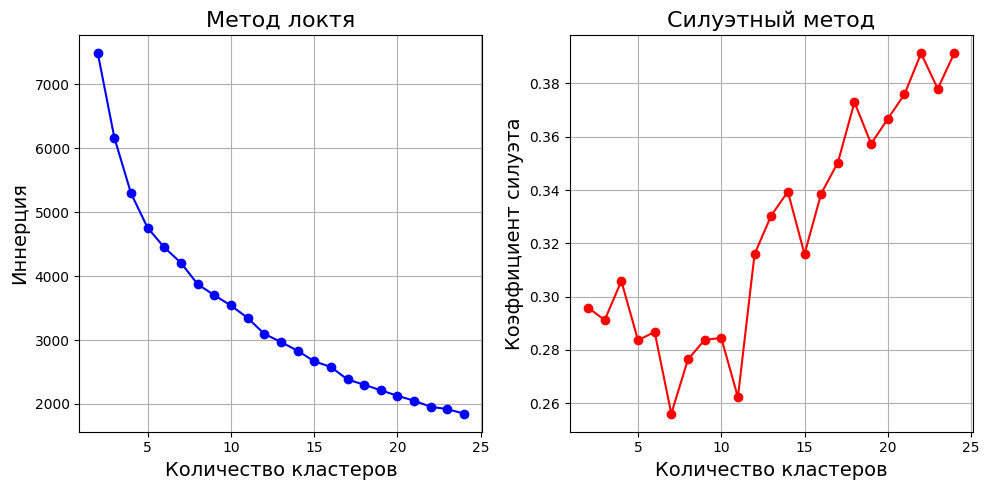

In [28]:
# 2. Определение оптимального числа кластеров
# Метод локтя и силуэтный анализ
inertia = []
silhouette_scores = []
k_range = range(2, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    
    if k > 1:  # silhouette_score требует как минимум 2 кластера
        silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

# Визуализация метода локтя
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Количество кластеров', fontsize=14)
plt.ylabel('Иннерция', fontsize=14)
plt.title('Метод локтя', fontsize=16)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Количество кластеров', fontsize=14)
plt.ylabel('Коэффициент силуэта', fontsize=14)
plt.title('Силуэтный метод', fontsize=16)
plt.grid(True)

plt.tight_layout()
plt.savefig(f'{standart}/elbow_shilouette_{standart}.png')
plt.show()

In [37]:
# 3. Кластеризация K-means (выберем оптимальное k на основе графиков)
optimal_k = 10 # Можете изменить на основе графиков выше
img_dir = f"{standart}/clusters{optimal_k}"
os.makedirs(img_dir, exist_ok=True)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=15)
cluster_labels = kmeans.fit_predict(scaled_data)

# Добавляем метки кластеров в исходные данные
clustering_data = clustering_data.copy()
clustering_data['cluster'] = cluster_labels
print(clustering_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   f1              700 non-null    float64
 1   f2              700 non-null    float64
 2   f3              700 non-null    float64
 3   f4              700 non-null    float64
 4   f5              700 non-null    float64
 5   Aq1             700 non-null    float64
 6   Aq2             700 non-null    float64
 7   Aq3             700 non-null    float64
 8   Aq4             700 non-null    float64
 9   Aq5             700 non-null    float64
 10  phase1          700 non-null    float64
 11  phase2          700 non-null    float64
 12  phase3          700 non-null    float64
 13  phase4          700 non-null    float64
 14  phase5          700 non-null    float64
 15  amplitude_norm  700 non-null    float64
 16  cluster         700 non-null    int32  
dtypes: float64(16), int32(1)
memory usa

In [38]:
# 4. Анализ кластеров
print("\nРазмеры кластеров:")
print(clustering_data['cluster'].value_counts().sort_index())

# Средние значения по кластерам
cluster_means = clustering_data.groupby('cluster').mean()
print("\nСредние значения по кластерам:")
print(cluster_means)


Размеры кластеров:
cluster
0    204
1     67
2     82
3     57
4     14
5     63
6     51
7     57
8     51
9     54
Name: count, dtype: int64

Средние значения по кластерам:
               f1        f2        f3        f4        f5       Aq1       Aq2  \
cluster                                                                         
0        1.197645  2.385682  0.026471  0.001471  0.000000  0.999094  0.033331   
1        1.142983  0.854028  1.886563  0.142089  0.120597  0.929077  0.345178   
2        1.121705  0.494145  0.542438  0.519511  0.689999  0.815054  0.350128   
3        1.645260  2.623854  0.989472  2.062101  1.819295  0.998820  0.030796   
4        0.459999  0.919998  1.379997  1.839996  0.648570  0.809563  0.425817   
5        1.076188  0.886347  0.479682  1.312696  1.218410  0.910385  0.327439   
6        0.974900  1.560389  1.944702  0.977253  0.788234  0.973499  0.197948   
7        1.309471  2.420346  2.072627  0.543859  0.079649  0.998985  0.031944   
8        1.233

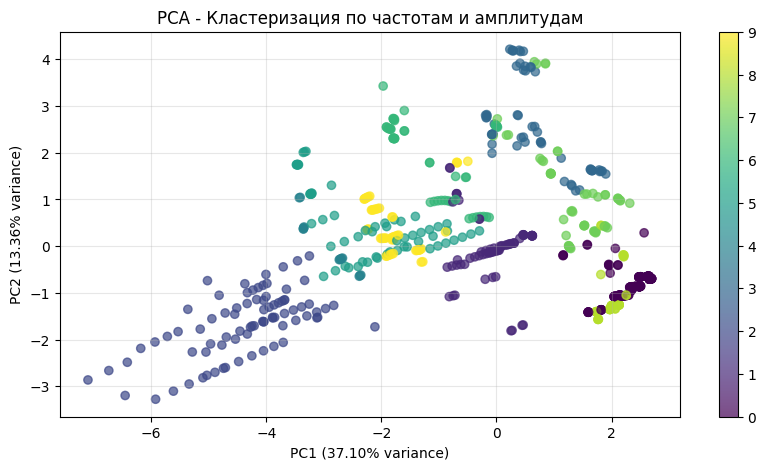

In [39]:
# 5. PCA для визуализации кластеров в пространстве признаков
pca_features = PCA(n_components=2)
pca_result_features = pca_features.fit_transform(scaled_data)

plt.figure(figsize=(10, 5))
scatter = plt.scatter(pca_result_features[:, 0], pca_result_features[:, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel(f'PC1 ({pca_features.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_features.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA - Кластеризация по частотам и амплитудам')
plt.grid(True, alpha=0.3)
plt.savefig(f'{img_dir}/PCA_cluster{optimal_k}_phase_{standart}.png')

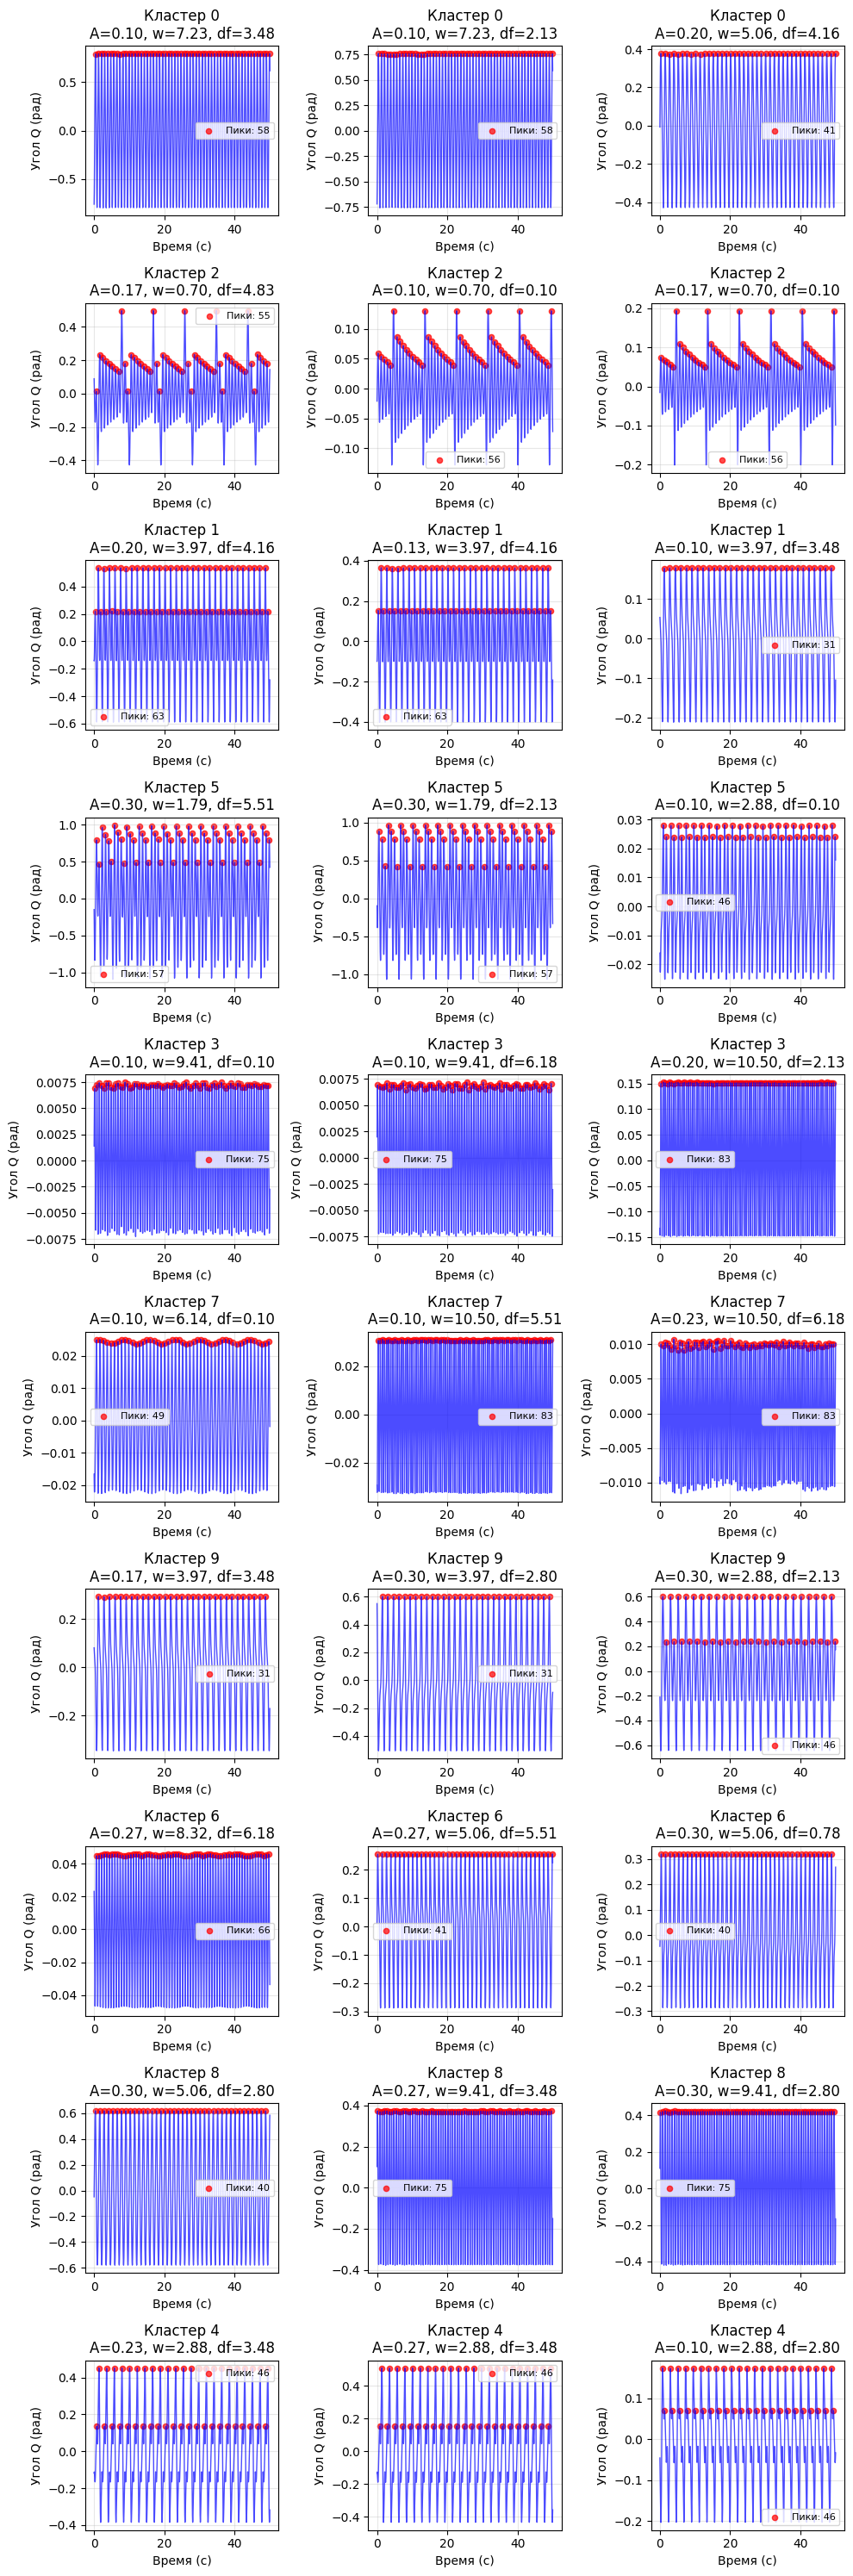

In [40]:
def plot_detailed_cluster_trajectories(spectrum_df, cluster_labels, results_dir="results", n_clusters_to_plot=3):
    """
    Детальная визуализация с дополнительной информацией о кластерах
    """
    
    spectrum_df_clustered = spectrum_df.copy()
    spectrum_df_clustered['cluster'] = cluster_labels
    
    # Выбираем наиболее представительные кластеры (с наибольшим количеством точек)
    cluster_counts = spectrum_df_clustered['cluster'].value_counts()
    clusters_to_plot = cluster_counts.head(n_clusters_to_plot).index
    
    fig = plt.figure(figsize=(10, 3 * n_clusters_to_plot))
    
    for i, cluster_id in enumerate(clusters_to_plot):
        cluster_data = spectrum_df_clustered[spectrum_df_clustered['cluster'] == cluster_id]
        
        # Выбираем 3 представителя из кластера
        representatives = cluster_data.sample(min(3, len(cluster_data)), random_state=42)
        
        for j, (_, row) in enumerate(representatives.iterrows()):
            try:
                # Создаем subplot для каждого представителя
                ax1 = plt.subplot(n_clusters_to_plot, 3, i * 3 + j + 1)
                
                # Загружаем данные
                data = np.load(os.path.join(results_dir, row['results_file']))
                Q = data['Q']
                T = data['T']
                
                # Применяем маску и коррекцию
                mask = T > 15 * 1000
                Q_masked = Q[mask] - np.pi/2
                T_masked = T[mask]
                T_normalized = (T_masked - T_masked[0]) / 1000
                
                # Траектория угла
                ax1.plot(T_normalized, Q_masked, 'b-', alpha=0.7, linewidth=1)
                ax1.set_title(f'Кластер {cluster_id}\nA={row["A"]:.2f}, w={row["w"]:.2f}, df={row["df"]:.2f}')
                ax1.set_xlabel('Время (с)')
                ax1.set_ylabel('Угол Q (рад)')
                ax1.grid(True, alpha=0.3)
                
                # Добавляем информацию о пиках
                peaks, _ = find_peaks(Q_masked, height=0)
                if len(peaks) > 0:
                    ax1.scatter(T_normalized[peaks], Q_masked[peaks], 
                              color='red', s=20, alpha=0.7, label=f'Пики: {len(peaks)}')
                    ax1.legend(fontsize=8)
                
            except Exception as e:
                print(f"Ошибка при загрузке файла {row['results_file']}: {e}")
                # Создаем пустой subplot с сообщением об ошибке
                ax1 = plt.subplot(n_clusters_to_plot, 3, i * 3 + j + 1)
                ax1.text(0.5, 0.5, f'Ошибка загрузки\n{e}', 
                        ha='center', va='center', transform=ax1.transAxes)
                ax1.set_title(f'Кластер {cluster_id} - Ошибка')
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Детальная версия
fig3 = plot_detailed_cluster_trajectories(spectrum_df, cluster_labels, 
                                        results_dir="results", 
                                        n_clusters_to_plot=optimal_k)
fig3.savefig(f'{img_dir}/clusters{optimal_k }_{standart}.png')

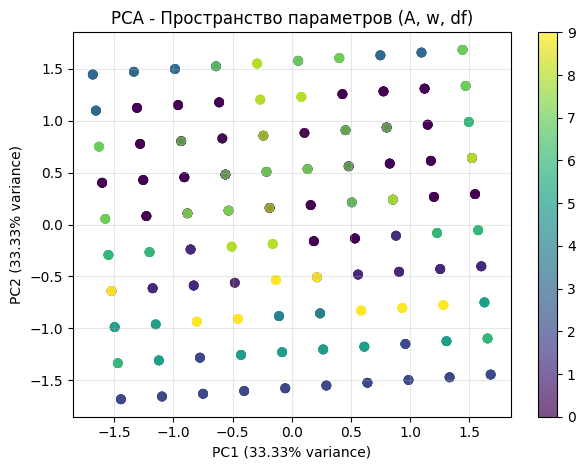

In [41]:
# 6. PCA в пространстве параметров (A, w, df)
params_for_pca = ['A', 'w', 'df']
params_data = spectrum_df[params_for_pca].values

# Стандартизация параметров
params_scaler = StandardScaler()
scaled_params = params_scaler.fit_transform(params_data)

# PCA для параметров
pca_params = PCA(n_components=2)
pca_result_params = pca_params.fit_transform(scaled_params)

# Используем цвета кластеров для соответствующих точек
valid_indices = clustering_data.index  # индексы данных, которые были использованы в кластеризации
scatter = plt.scatter(pca_result_params[valid_indices, 0], 
                     pca_result_params[valid_indices, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel(f'PC1 ({pca_params.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_params.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA - Пространство параметров (A, w, df)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{img_dir}/PCA_Awdf_cluster{optimal_k }_{standart}.png')
plt.show()

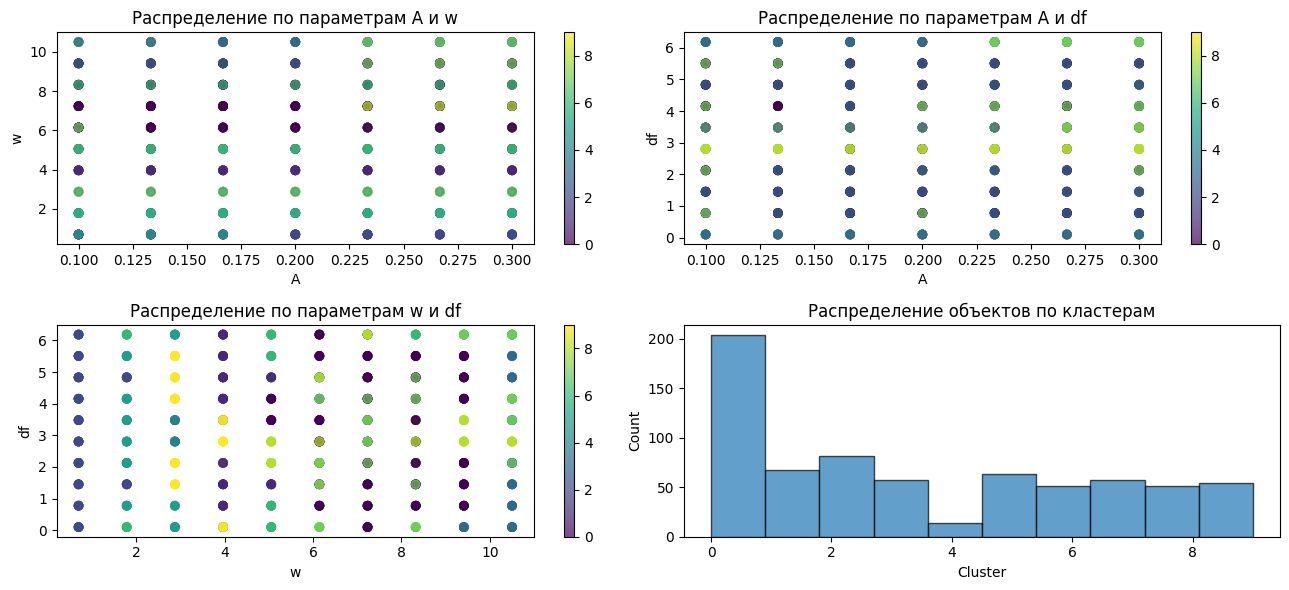

In [42]:
# 7. Дополнительная визуализация - распределение параметров по кластерам
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# A vs w с кластерами
scatter = axes[0, 0].scatter(spectrum_df.loc[valid_indices, 'A'], 
                            spectrum_df.loc[valid_indices, 'w'], 
                            c=cluster_labels, cmap='viridis', alpha=0.7)
axes[0, 0].set_xlabel('A')
axes[0, 0].set_ylabel('w')
axes[0, 0].set_title('Распределение по параметрам A и w')
plt.colorbar(scatter, ax=axes[0, 0])

# A vs df с кластерами
scatter = axes[0, 1].scatter(spectrum_df.loc[valid_indices, 'A'], 
                            spectrum_df.loc[valid_indices, 'df'], 
                            c=cluster_labels, cmap='viridis', alpha=0.7)
axes[0, 1].set_xlabel('A')
axes[0, 1].set_ylabel('df')
axes[0, 1].set_title('Распределение по параметрам A и df')
plt.colorbar(scatter, ax=axes[0, 1])

# w vs df с кластерами
scatter = axes[1, 0].scatter(spectrum_df.loc[valid_indices, 'w'], 
                            spectrum_df.loc[valid_indices, 'df'], 
                            c=cluster_labels, cmap='viridis', alpha=0.7)
axes[1, 0].set_xlabel('w')
axes[1, 0].set_ylabel('df')
axes[1, 0].set_title('Распределение по параметрам w и df')
plt.colorbar(scatter, ax=axes[1, 0])

# Гистограмма распределения по кластерам
axes[1, 1].hist(cluster_labels, bins=optimal_k, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Распределение объектов по кластерам')

plt.tight_layout()
plt.savefig(f'{img_dir}/distibutions_cluster{optimal_k }_{standart}.png')
plt.show()

In [44]:
!pwd

/home/nickolai/нейроморф/CatProj/ER2025
